<a href="https://colab.research.google.com/github/aishamuqadus993-commits/Brain_Tumor_app/blob/main/Brain%20Tumooooor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [ ]:

# CELL 1 — IMPORTS
import os, cv2, random, json, pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
print(f"TensorFlow version: {tf.__version__}")
print("All imports done.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
✅ All imports done.


Dataset Verification

In [ ]:
import os
from pathlib import Path
from collections import defaultdict

def verify_dataset(dataset_dir):


    IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    LABEL_EXTS = {'.txt', '.xml', '.json'}

    dataset_dir = Path(dataset_dir)

    print("=" * 60)
    print(f"  Dataset Verification: {dataset_dir}")
    print("=" * 60)

    # ── 1. Collect all image files recursively
    all_images = [
        p for p in dataset_dir.rglob('*')
        if p.suffix.lower() in IMAGE_EXTS
    ]

    print(f"\n[1] Total images found : {len(all_images)}")

    if not all_images:
        print("  No images found!")
        return

    # ── 2. Check for corrupted / zero-byte images
    corrupted = []
    for img in all_images:
        if img.stat().st_size == 0:
            corrupted.append(img)

    print(f"[2] Zero-byte (corrupt) images: {len(corrupted)}")
    if corrupted:
        for f in corrupted:
            print(f" {f}")

    # ── 3. Check for duplicate filenames
    name_map = defaultdict(list)
    for img in all_images:
        name_map[img.name].append(img)

    duplicates = {k: v for k, v in name_map.items() if len(v) > 1}
    print(f"[3] Duplicate filenames  : {len(duplicates)}")
    if duplicates:
        for name, paths in duplicates.items():
            print(f"      {name}")
            for p in paths:
                print(f"        {p}")

    # ── 4. Per-class breakdown (if class-folders exist)
    class_counts = defaultdict(int)
    for img in all_images:
        # parent folder = class name (e.g. dataset/cats/img.jpg)
        class_counts[img.parent.name] += 1

    print(f"\n[4] Class breakdown ({len(class_counts)} classes):")
    for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
        print(f"    {cls:<30} {count} images")

    # ── 5. Label files check (optional)
    label_dirs = [d for d in dataset_dir.rglob('labels') if d.is_dir()]
    if label_dirs:
        print(f"\n[5] Label folders found : {label_dirs}")
        for label_dir in label_dirs:
            labels = [p for p in label_dir.rglob('*') if p.suffix.lower() in LABEL_EXTS]
            print(f"    Labels in {label_dir.name}/ : {len(labels)}")

            # Match images vs labels
            img_stems = {p.stem for p in all_images}
            lbl_stems = {p.stem for p in labels}

            missing_labels = img_stems - lbl_stems
            extra_labels   = lbl_stems - img_stems

            print(f"    Images without labels : {len(missing_labels)}")
            print(f"    Labels without images : {len(extra_labels)}")

            if missing_labels:
                print("    Missing labels for:")
                for s in list(missing_labels)[:10]:   # show first 10
                    print(f"        {s}")

            if extra_labels:
                print(" Extra label files:")
                for s in list(extra_labels)[:10]:
                    print(f"        {s}")
    else:
        print("\n[5] No 'labels/' folder found — skipping label check.")

    # ── 6. Summary
    print("\n" + "=" * 60)
    print("  SUMMARY")
    print("=" * 60)
    print(f"  Total images   : {len(all_images)}")
    print(f"  Corrupted      : {len(corrupted)}")
    print(f"  Duplicates     : {len(duplicates)}")
    print(f"  Classes        : {len(class_counts)}")
    if len(corrupted) == 0 and len(duplicates) == 0:
        print("\n  Dataset looks clean! Ready to split.")
    else:
        print("\n  Fix the above issues before splitting.")
    print("=" * 60)


# ── Run it
verify_dataset("/content/drive/MyDrive/MRI Imgs")

  Dataset Verification: /content/drive/MyDrive/MRI Imgs

[1] Total images found : 10560
[2] Zero-byte (corrupt) images: 0
[3] Duplicate filenames  : 0

[4] Class breakdown (4 classes):
    glioma                         3754 images
    pituitary                      2706 images
    meningioma                     2343 images
    no_tumor                       1757 images

[5] No 'labels/' folder found — skipping label check.

  SUMMARY
  Total images   : 10560
  Corrupted      : 0
  Duplicates     : 0
  Classes        : 4

  ✅ Dataset looks clean! Ready to split.


Splitting of Dataset

In [ ]:
import os
import shutil
import random
from pathlib import Path

def split_dataset(dataset_dir, output_dir, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Split dataset into train, val, and test sets.

    """

    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1.0"

    IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    random.seed(seed)

    dataset_dir = Path(dataset_dir)
    output_dir  = Path(output_dir)

    print("=" * 60)
    print(f"  Splitting Dataset : {dataset_dir.name}")
    print(f"  Train : Val : Test = {train_ratio} : {val_ratio} : {test_ratio}")
    print("=" * 60)

    # Get all class folders
    class_dirs = [d for d in dataset_dir.iterdir() if d.is_dir()]

    if not class_dirs:
        print("No class subfolders found. Check your dataset path.")
        return

    split_summary = {}

    for class_dir in sorted(class_dirs):
        class_name = class_dir.name

        # Collect all images
        images = [f for f in class_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS]
        random.shuffle(images)

        total = len(images)
        if total == 0:
            print(f"  No images found in class: {class_name}")
            continue

        # Calculate split sizes
        n_train = int(total * train_ratio)
        n_val   = int(total * val_ratio)
        n_test  = total - n_train - n_val  # remainder goes to test

        train_imgs = images[:n_train]
        val_imgs   = images[n_train:n_train + n_val]
        test_imgs  = images[n_train + n_val:]

        # Copy files to output folders
        for split, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
            dest_dir = output_dir / split / class_name
            dest_dir.mkdir(parents=True, exist_ok=True)
            for img in split_imgs:
                shutil.copy2(img, dest_dir / img.name)

        split_summary[class_name] = {
            'total': total,
            'train': len(train_imgs),
            'val'  : len(val_imgs),
            'test' : len(test_imgs)
        }

        print(f"\n  Class: {class_name}")
        print(f"    Total : {total}")
        print(f"    Train : {len(train_imgs)}")
        print(f"    Val   : {len(val_imgs)}")
        print(f"    Test  : {len(test_imgs)}")

    # Final summary
    print("\n" + "=" * 60)
    print("  SPLIT SUMMARY")
    print("=" * 60)
    total_all = sum(v['total'] for v in split_summary.values())
    train_all = sum(v['train'] for v in split_summary.values())
    val_all   = sum(v['val']   for v in split_summary.values())
    test_all  = sum(v['test']  for v in split_summary.values())

    print(f"  Classes        : {len(split_summary)}")
    print(f"  Total images   : {total_all}")
    print(f"  Train images   : {train_all}")
    print(f"  Val images     : {val_all}")
    print(f"  Test images    : {test_all}")
    print(f"\n  Split complete! Output saved to: {output_dir}")
    print("=" * 60)

    # Show output folder structure
    print("\n  Output Structure:")
    print(f"  {output_dir.name}/")
    for split in ['train', 'val', 'test']:
        print(f"  ├── {split}/")
        for cls in sorted(split_summary.keys()):
            print(f"  │     ├── {cls}/")


# ── Run it
split_dataset(
    dataset_dir = "/content/drive/MyDrive/MRI Imgs",        # dataset folder
    output_dir  = "/content/drive/MyDrive/MRI Imgs Split",  # where split data will be saved
    train_ratio = 0.70,
    val_ratio   = 0.15,
    test_ratio  = 0.15,
    seed        = 42                 # for reproducibility
)


  Splitting Dataset : MRI Imgs
  Train : Val : Test = 0.7 : 0.15 : 0.15

  Class: glioma
    Total : 3754
    Train : 2627
    Val   : 563
    Test  : 564

  Class: meningioma
    Total : 2343
    Train : 1640
    Val   : 351
    Test  : 352

  Class: no_tumor
    Total : 1757
    Train : 1229
    Val   : 263
    Test  : 265

  Class: pituitary
    Total : 2706
    Train : 1894
    Val   : 405
    Test  : 407

  SPLIT SUMMARY
  Classes        : 4
  Total images   : 10560
  Train images   : 7390
  Val images     : 1582
  Test images    : 1588

  ✅ Split complete! Output saved to: /content/drive/MyDrive/MRI Imgs Split

  Output Structure:
  MRI Imgs Split/
  ├── train/
  │     ├── glioma/
  │     ├── meningioma/
  │     ├── no_tumor/
  │     ├── pituitary/
  ├── val/
  │     ├── glioma/
  │     ├── meningioma/
  │     ├── no_tumor/
  │     ├── pituitary/
  ├── test/
  │     ├── glioma/
  │     ├── meningioma/
  │     ├── no_tumor/
  │     ├── pituitary/


In [ ]:

# CELL 2 — CONFIG (single place, change nothing else)
# Paths
TRAIN_DIR     = "/content/drive/MyDrive/MRI Imgs Split/train"
VAL_DIR       = "/content/drive/MyDrive/MRI Imgs Split/val"
TEST_DIR      = "/content/drive/MyDrive/MRI Imgs Split/test"
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

# Model config
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
EPOCHS_P1   = 10
EPOCHS_P2   = 15
LR_P1       = 1e-3
LR_P2       = 1e-5
LABEL_SMOOTH= 0.1

# Class names
CLASS_NAMES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
    and not d.startswith('.')
])
NUM_CLASSES = len(CLASS_NAMES)

CLASS_COLORS = {
    'glioma'    : '#E74C3C',
    'meningioma': '#9B59B6',
    'no_tumor'  : '#27AE60',
    'pituitary' : '#F39C12',
}

print(f"Classes : {CLASS_NAMES}")
print(f"Num     : {NUM_CLASSES}")
print("Config ready.")

Classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Num     : 4
✅ Config ready.


Visualisation

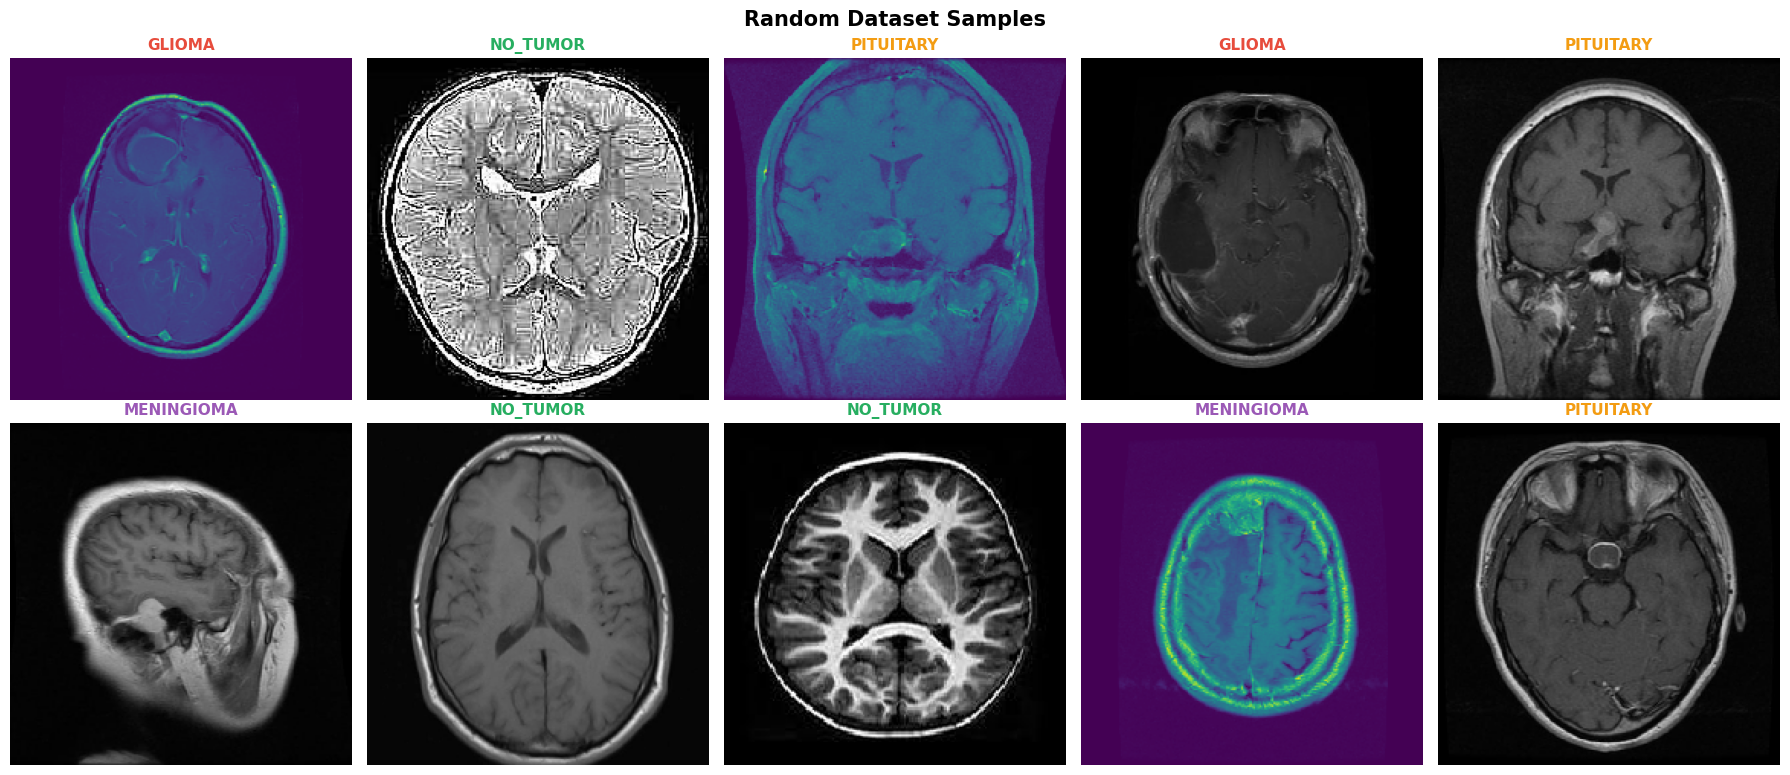

✅ Visualization done.


In [ ]:

# CELL 3 — VISUALIZE RANDOM IMAGES FROM DATASET
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle("Random Dataset Samples", fontsize=15, fontweight='bold')
axes = axes.flatten()

all_samples = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs    = [f for f in os.listdir(cls_dir)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for fname in random.sample(imgs, min(3, len(imgs))):
        all_samples.append((os.path.join(cls_dir, fname), cls))

random.shuffle(all_samples)
samples = all_samples[:10]

for i, (path, cls) in enumerate(samples):
    img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    axes[i].imshow(img)
    axes[i].set_title(cls.upper(), fontsize=11, fontweight='bold',
                      color=CLASS_COLORS.get(cls, '#000'))
    axes[i].axis('off')
    for spine in axes[i].spines.values():
        spine.set_edgecolor(CLASS_COLORS.get(cls,'#000'))
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "dataset_samples.png"), dpi=150)
plt.show()
print("Visualization done.")

Preprocessing

In [ ]:

# CELL 5 — PREPROCESSING + DATA GENERATORS
def get_generators():

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1
    )
    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    train_data = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
        shuffle=True
    )
    val_data = val_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
        shuffle=False
    )
    return train_data, val_data

train_data, val_data = get_generators()
print(f"\nTrain samples : {train_data.samples}")
print(f"Val   samples : {val_data.samples}")
print(f"Train batches : {len(train_data)}")
print(f"Val   batches : {len(val_data)}")
print(f"Class indices : {train_data.class_indices}")
print("Generators ready.")

Found 7390 images belonging to 4 classes.
Found 1582 images belonging to 4 classes.

Train samples : 7390
Val   samples : 1582
Train batches : 231
Val   batches : 50
Class indices : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
✅ Generators ready.


Building Model

In [ ]:

# CELL 6 — BUILD MODEL
# VGG16:

def build_model():
    base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )
    base.trainable = False  # frozen for phase 1

    x   = base.output
    x   = Flatten()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    x   = Dense(128, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base

model, base = build_model()

# Print trainable summary
total     = sum(p.numpy() for p in model.trainable_weights
                for p in [tf.size(p)])
print(f"\nTotal layers    : {len(model.layers)}")
print(f"Trainable layers: "
      f"{sum(1 for l in model.layers if l.trainable)}")
print(" Model built.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Total layers    : 25
Trainable layers: 6
✅ Model built.


Phase 1 Training

In [ ]:

# CELL 7 — PHASE 1 TRAINING
# Backbone frozen — only top Dense layers train
model.compile(
    optimizer=Adam(LR_P1),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

ckpt_p1 = os.path.join(MODEL_OUT_DIR, 'vgg16_phase1_best.keras')

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_P1,
    callbacks=[
        ModelCheckpoint(ckpt_p1, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]
)

# Save history immediately — avoids loss on disconnect
with open(os.path.join(MODEL_OUT_DIR, "history_p1.json"), "w") as f:
    json.dump(history1.history, f)

print(f"\n Phase 1 done.")
print(f"   Best val_accuracy : {max(history1.history['val_accuracy']):.4f}")
print(f"   History saved.")

Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.4958 - loss: 7.3284
Epoch 1: val_accuracy improved from None to 0.66119, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 235s 944ms/step - accuracy: 0.5031 - loss: 3.4071 - val_accuracy: 0.6612 - val_loss: 0.9579 - learning_rate: 0.0010
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.5253 - loss: 1.1883
Epoch 2: val_accuracy improved from 0.66119 to 0.70544, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 178s 769ms/step - accuracy: 0.5304 - loss: 1.1827 - val_accuracy: 0.7054 - val_loss: 0.8308 - learning_rate: 0.0010
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.570

Phase 2 Traiing

In [ ]:

# CELL 8 — PHASE 2 FINE-TUNING
# Unfreeze block5 only — last conv block of VGG16
for layer in base.layers:
    layer.trainable = 'block5' in layer.name

print("Unfrozen layers:")
for l in model.layers:
    if l.trainable and 'block5' in l.name:
        print(f"  ✅ {l.name}")

model.compile(
    optimizer=Adam(LR_P2),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

ckpt_p2 = os.path.join(MODEL_OUT_DIR, 'vgg16_phase2_best.keras')

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_P2,
    callbacks=[
        ModelCheckpoint(ckpt_p2, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]
)

# Save history immediately
with open(os.path.join(MODEL_OUT_DIR, "history_p2.json"), "w") as f:
    json.dump(history2.history, f)

print(f"\n Phase 2 done.")
print(f"   Best val_accuracy : {max(history2.history['val_accuracy']):.4f}")
print(f"   History saved.")

Unfrozen layers:
  ✅ block5_conv1
  ✅ block5_conv2
  ✅ block5_conv3
  ✅ block5_pool
Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.7437 - loss: 0.8310
Epoch 1: val_accuracy improved from None to 0.90645, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 193s 800ms/step - accuracy: 0.7518 - loss: 0.8166 - val_accuracy: 0.9064 - val_loss: 0.6209 - learning_rate: 1.0000e-05
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.7575 - loss: 0.8059
Epoch 2: val_accuracy improved from 0.90645 to 0.92478, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 180s 781ms/step - accuracy: 0.7641 - loss: 0.7972 - val_accuracy: 0.9248 - val_loss: 0.6166 - learn

Saving Model

In [ ]:

# CELL 9 — SAVE FINAL MODEL + METADATA
final_path = os.path.join(MODEL_OUT_DIR, 'vgg16_final.keras')
model.save(final_path)
print(f" Model saved → {final_path}")

metadata = {
    "class_names"    : CLASS_NAMES,
    "num_classes"    : NUM_CLASSES,
    "image_size"     : IMAGE_SIZE,
    "conf_threshold" : 0.45,
    "entropy_threshold": 0.82,
    "architecture"   : "VGG16+Dense256+Dense128+Softmax4",
}
with open(os.path.join(MODEL_OUT_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved.")

# Verify files exist
for fname in ['vgg16_final.keras', 'metadata.json',
              'vgg16_phase1_best.keras', 'vgg16_phase2_best.keras',
              'history_p1.json', 'history_p2.json']:
    path   = os.path.join(MODEL_OUT_DIR, fname)
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e6 if exists else 0
    print(f"  {'✅' if exists else '❌'} {fname:<35} {size:.1f} MB")

✅ Model saved → /content/drive/MyDrive/model_artifacts/vgg16_final.keras
✅ Metadata saved.
  ✅ vgg16_final.keras                   193.1 MB
  ✅ metadata.json                       0.0 MB
  ✅ vgg16_phase1_best.keras             136.4 MB
  ✅ vgg16_phase2_best.keras             193.1 MB
  ✅ history_p1.json                     0.0 MB
  ✅ history_p2.json                     0.0 MB


Graphs

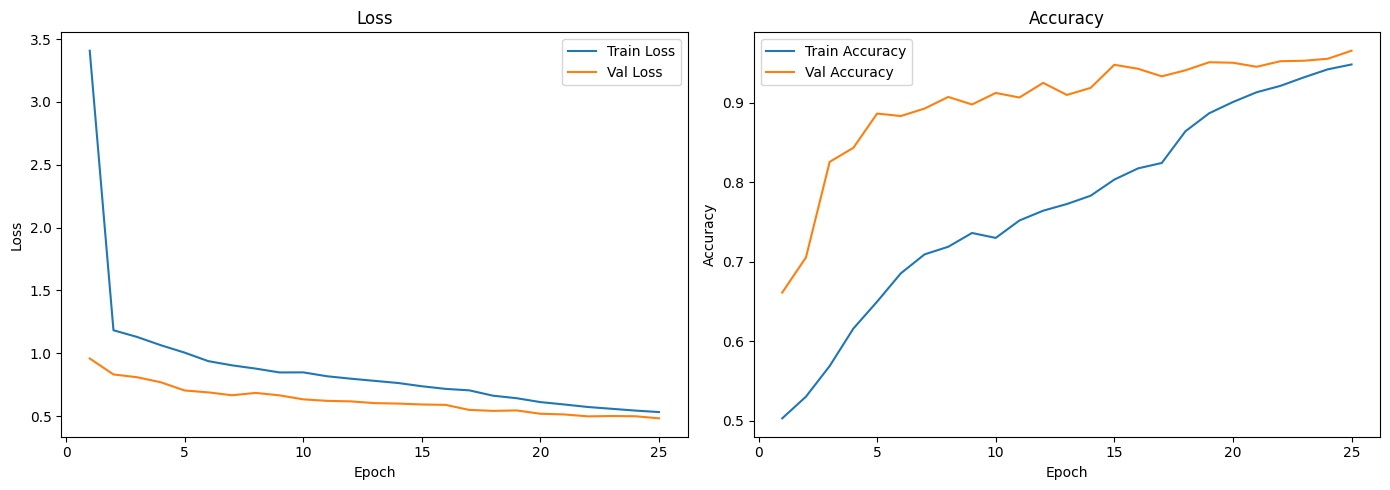

In [ ]:

# CELL 1 — LOSS & ACCURACY GRAPHS
import matplotlib.pyplot as plt

# Phase 1
p1_train_loss = [3.4071, 1.1827, 1.1290, 1.0633, 1.0045, 0.9367, 0.9034, 0.8773, 0.8468, 0.8474]
p1_val_loss   = [0.9579, 0.8308, 0.8087, 0.7684, 0.7034, 0.6882, 0.6653, 0.6840, 0.6645, 0.6327]
p1_train_acc  = [0.5031, 0.5304, 0.5689, 0.6160, 0.6498, 0.6854, 0.7092, 0.7188, 0.7361, 0.7299]
p1_val_acc    = [0.6612, 0.7054, 0.8255, 0.8432, 0.8862, 0.8831, 0.8925, 0.9071, 0.8976, 0.9121]

# Phase 2
p2_train_loss = [0.8166, 0.7972, 0.7800, 0.7628, 0.7370, 0.7160, 0.7044, 0.6619, 0.6417, 0.6108, 0.5920, 0.5719, 0.5576, 0.5433, 0.5315]
p2_val_loss   = [0.6209, 0.6166, 0.6027, 0.5991, 0.5919, 0.5888, 0.5487, 0.5410, 0.5445, 0.5181, 0.5126, 0.4974, 0.5000, 0.4983, 0.4816]
p2_train_acc  = [0.7518, 0.7641, 0.7725, 0.7829, 0.8032, 0.8173, 0.8241, 0.8640, 0.8866, 0.9007, 0.9130, 0.9210, 0.9318, 0.9418, 0.9479]
p2_val_acc    = [0.9064, 0.9248, 0.9096, 0.9185, 0.9475, 0.9425, 0.9330, 0.9406, 0.9507, 0.9501, 0.9450, 0.9520, 0.9526, 0.9551, 0.9652]

train_loss = p1_train_loss + p2_train_loss
val_loss   = p1_val_loss   + p2_val_loss
train_acc  = p1_train_acc  + p2_train_acc
val_acc    = p1_val_acc    + p2_val_acc

epochs = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_loss, label='Train Loss')
ax1.plot(epochs, val_loss,   label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, train_acc, label='Train Accuracy')
ax2.plot(epochs, val_acc,   label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()


Confusion Matrix (Test)

⏳ Loading model...
✅ Model loaded!
Found 1588 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 549ms/step


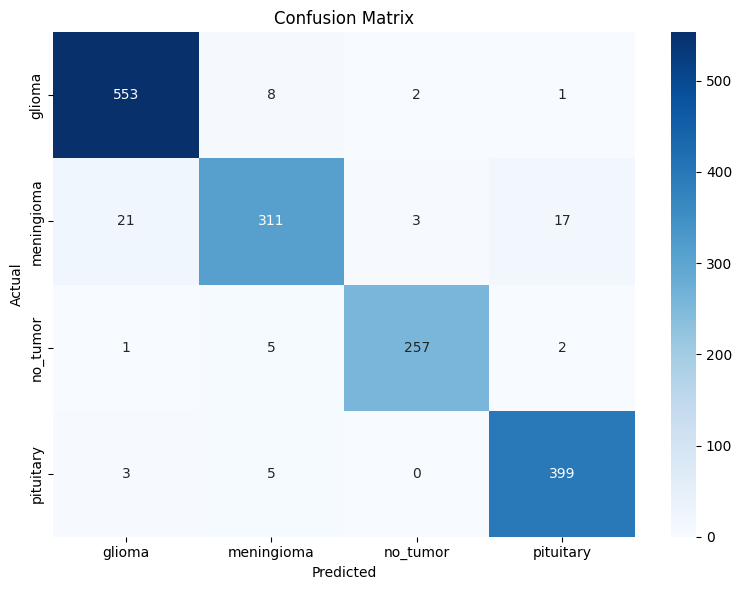

              precision    recall  f1-score   support

      glioma       0.96      0.98      0.97       564
  meningioma       0.95      0.88      0.91       352
    no_tumor       0.98      0.97      0.98       265
   pituitary       0.95      0.98      0.97       407

    accuracy                           0.96      1588
   macro avg       0.96      0.95      0.96      1588
weighted avg       0.96      0.96      0.96      1588



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
import os
import json
from tensorflow.keras.models import load_model

# Load model and metadata if not already loaded
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
MODEL_PATH    = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras")
META_PATH     = os.path.join(MODEL_OUT_DIR, "metadata.json")

# Load metadata
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES       = meta["class_names"]
IMAGE_SIZE        = meta["image_size"]

# Load model
if 'model' not in locals(): # Check if model is already loaded
    print("Loading model...")
    model = load_model(MODEL_PATH)
    print(" Model loaded!")

# CELL 2 — CONFUSION MATRIX

TEST_DIR    = '/content/drive/MyDrive/MRI Imgs Split/test'

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    TEST_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Validation Evaluation

⏳ Loading model...
✅ Model loaded!
Found 1582 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 1182s 24s/step

  CLASSIFICATION REPORT — VALIDATION SET
              precision    recall  f1-score   support

      glioma     0.9652    0.9840    0.9745       563
  meningioma     0.9721    0.8946    0.9318       351
    no_tumor     0.9774    0.9886    0.9830       263
   pituitary     0.9523    0.9852    0.9684       405

    accuracy                         0.9652      1582
   macro avg     0.9668    0.9631    0.9644      1582
weighted avg     0.9654    0.9652    0.9649      1582



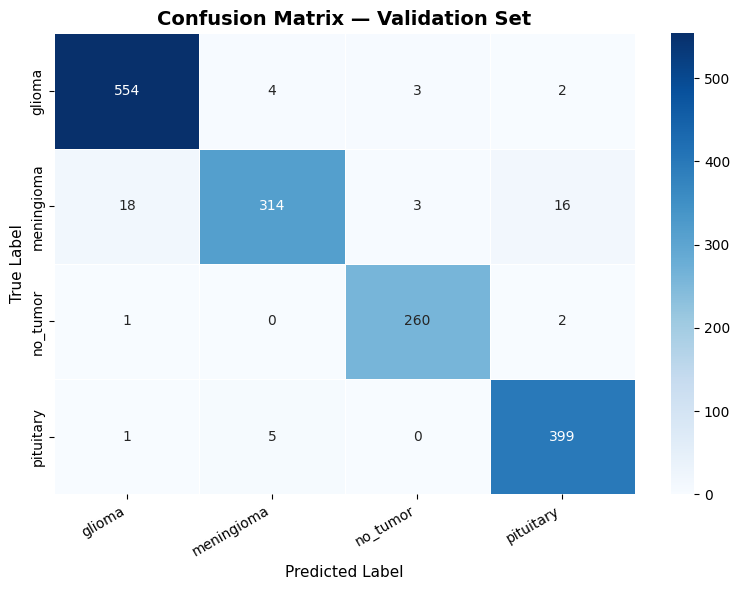

In [ ]:

# VALIDATION — CONFUSION MATRIX + CLASSIFICATION REPORT
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Added for os.path.join
import json # Added for json.load
from tensorflow.keras.models import load_model # Added for load_model

# Define paths and load metadata (copied from config cell and metadata loading logic)
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
META_PATH     = os.path.join(MODEL_OUT_DIR, "metadata.json")
MODEL_PATH    = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras") # Define MODEL_PATH

# Load metadata
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES = meta["class_names"]
IMAGE_SIZE  = meta["image_size"]

# Define other necessary variables (from config cell)
VAL_DIR     = "/content/drive/MyDrive/MRI Imgs Split/val"
BATCH_SIZE  = 32

# Load the model
print("Loading model...")
model = load_model(MODEL_PATH)
print(" Model loaded!")

# ── Validation Generator (shuffle=False for correct alignment)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    VAL_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

# ── Predictions
y_probs = model.predict(val_gen, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)
y_true  = val_gen.classes

# ── Classification Report
print("\n" + "="*55)
print("  CLASSIFICATION REPORT — VALIDATION SET")
print("="*55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ── Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "confusion_matrix_val.png"), dpi=150)
plt.show()

In [ ]:
# ── Reload everything fresh
import os, json, cv2
import numpy as np
from google.colab import drive
from tensorflow.keras.models import load_model

# Mount drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# Config
MODEL_OUT_DIR  = "/content/drive/MyDrive/model_artifacts"
MODEL_PATH     = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras")
META_PATH      = os.path.join(MODEL_OUT_DIR, "metadata.json")

# Load metadata
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES       = meta["class_names"]
IMAGE_SIZE        = meta["image_size"]
CONF_THRESHOLD    = meta["conf_threshold"]
ENTROPY_THRESHOLD = meta["entropy_threshold"]
NUM_CLASSES       = meta["num_classes"]

# Load model
print(" Loading model...")
model = load_model(MODEL_PATH)
print(" Ready!")


In [ ]:

# ── Reload everything fresh
import os, json, cv2
import numpy as np
from google.colab import drive
from tensorflow.keras.models import load_model

# Mount drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# Config
MODEL_OUT_DIR  = "/content/drive/MyDrive/model_artifacts"
MODEL_PATH     = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras")
META_PATH      = os.path.join(MODEL_OUT_DIR, "metadata.json")

# Load metadata
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES       = meta["class_names"]
IMAGE_SIZE        = meta["image_size"]
CONF_THRESHOLD    = meta["conf_threshold"]
ENTROPY_THRESHOLD = meta["entropy_threshold"]
NUM_CLASSES       = meta["num_classes"]

# Load model
print(" Loading model...")
model = load_model(MODEL_PATH)
print("✅ Ready!")

# then rest of inference + gradio code below
# CELL 10 — INFERENCE PIPELINE

import numpy as np
import json
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import entropy as scipy_entropy

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import preprocess_input
from PIL import Image

# ── Load metadata
META_PATH  = os.path.join(MODEL_OUT_DIR, "metadata.json")
MODEL_PATH = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras")

with open(META_PATH, "r") as f:
    meta = json.load(f)

CLASS_NAMES       = meta["class_names"]
IMAGE_SIZE        = meta["image_size"]
CONF_THRESHOLD    = meta["conf_threshold"]      # 0.45
ENTROPY_THRESHOLD = meta["entropy_threshold"]   # 0.82
NUM_CLASSES       = meta["num_classes"]

print(f" Metadata loaded.")
print(f"   Classes          : {CLASS_NAMES}")
print(f"   Image size       : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"   Conf threshold   : {CONF_THRESHOLD}")
print(f"   Entropy threshold: {ENTROPY_THRESHOLD}")

# ── Load model
model = load_model(MODEL_PATH)
print(f" Model loaded from {MODEL_PATH}")


# MRI VALIDITY CHECKER
def is_valid_mri(image_path, debug=False):
    """
    Returns (is_valid: bool, reason: str)
    Checks image is likely a brain MRI and not a random photo.
    """
    try:
        img_bgr = cv2.imread(str(image_path))
        if img_bgr is None:
            return False, "Cannot read image file"

        h, w = img_bgr.shape[:2]

        # ── Check 1: Minimum size
        if h < 50 or w < 50:
            return False, "Image too small"

        # ── Check 2: Grayscale dominance
        # MRIs are grayscale — R, G, B channels should be similar
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        r, g, b = img_rgb[:,:,0].astype(float), img_rgb[:,:,1].astype(float), img_rgb[:,:,2].astype(float)
        rg_diff = np.mean(np.abs(r - g))
        rb_diff = np.mean(np.abs(r - b))
        gb_diff = np.mean(np.abs(g - b))
        color_deviation = (rg_diff + rb_diff + gb_diff) / 3

        if debug:
            print(f"   Color deviation  : {color_deviation:.2f}  (MRI should be < 30)")

        if color_deviation > 30:
            return False, f"Too colorful to be MRI (deviation={color_deviation:.1f})"

        # ── Check 3: Dark background ratio
        # MRI scans have significant black/dark background
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        dark_ratio = np.sum(gray < 30) / gray.size

        if debug:
            print(f"   Dark pixel ratio : {dark_ratio:.2f}  (MRI should be > 0.15)")

        if dark_ratio < 0.15:
            return False, f"Insufficient dark background (ratio={dark_ratio:.2f})"

        # ── Check 4: Not completely black
        mean_brightness = np.mean(gray)
        if mean_brightness < 5:
            return False, "Image is completely black"

        # ── Check 5: Structural content exists
        edges = cv2.Canny(gray, 30, 100)
        edge_ratio = np.sum(edges > 0) / edges.size
        if edge_ratio < 0.01:
            return False, "No structural content found"

        if debug:
            print(f"   Edge ratio       : {edge_ratio:.3f}  (should be > 0.01)")

        return True, "Valid MRI"

    except Exception as e:
        return False, f"Error reading image: {str(e)}"



# PREPROCESSOR —
def preprocess_image(image_path):
    """Load and preprocess image exactly as in training (Cell 5)."""
    img = Image.open(image_path).convert('RGB')        # grayscale→RGB same as ImageDataGenerator
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(img, dtype=np.float32)
    arr = preprocess_input(arr)                        # VGG16 preprocessing — matches Cell 5
    return np.expand_dims(arr, axis=0)                 # shape: (1, H, W, 3)

# CORE INFERENCE FUNCTION
def predict_mri(image_path, debug=False):
    """
    Full inference pipeline with MRI validation.
    Returns dict with prediction details.
    """
    image_path = Path(image_path)

    result = {
        "path"       : str(image_path),
        "valid_mri"  : False,
        "rejected"   : False,
        "reason"     : "",
        "prediction" : None,
        "confidence" : 0.0,
        "all_probs"  : {},
        "uncertain"  : False,
    }

    # ── Step 1: MRI validity check
    valid, reason = is_valid_mri(image_path, debug=debug)
    if not valid:
        result["rejected"] = True
        result["reason"]   = reason
        return result

    result["valid_mri"] = True

    # ── Step 2: Preprocess
    x = preprocess_image(image_path)

    # ── Step 3: Predict
    probs = model.predict(x, verbose=0)[0]             # shape: (NUM_CLASSES,)

    # ── Step 4: Entropy check (uncertainty)
    # High entropy = model is confused = unreliable prediction
    ent = scipy_entropy(probs, base=2)
    max_entropy = np.log2(NUM_CLASSES)                 # maximum possible entropy
    norm_entropy = ent / max_entropy                   # normalize to [0, 1]

    if debug:
        print(f"   Entropy (norm)   : {norm_entropy:.3f}  (threshold={ENTROPY_THRESHOLD})")

    if norm_entropy > ENTROPY_THRESHOLD:
        result["rejected"]  = True
        result["uncertain"] = True
        result["reason"]    = f"Prediction uncertain (entropy={norm_entropy:.2f})"
        return result

    # ── Step 5: Confidence check
    top_idx  = np.argmax(probs)
    top_conf = probs[top_idx]

    if top_conf < CONF_THRESHOLD:
        result["rejected"] = True
        result["reason"]   = f"Low confidence (conf={top_conf:.2f}, threshold={CONF_THRESHOLD})"
        return result

    # ── Step 6: Return prediction
    result["prediction"] = CLASS_NAMES[top_idx]
    result["confidence"] = float(top_conf)
    result["all_probs"]  = {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)}

    return result


# VISUALIZATION — with rejection screen
def visualize_prediction(image_path, result):
    """
    Shows result with black rejection screen for invalid images,
    or full prediction breakdown for valid MRIs.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#0a0a0a')

    # ── Left: Image
    ax_img = axes[0]
    ax_img.set_facecolor('black')

    if result["rejected"]:
        # BLACK SCREEN with rejection message
        ax_img.set_facecolor('black')
        ax_img.text(0.5, 0.55, ' REJECTED', transform=ax_img.transAxes,
                    fontsize=18, fontweight='bold', color='red',
                    ha='center', va='center')
        ax_img.text(0.5, 0.40, 'Please upload a valid\nMRI image',
                    transform=ax_img.transAxes,
                    fontsize=11, color='#aaaaaa',
                    ha='center', va='center')
        ax_img.text(0.5, 0.22, f'Reason:\n{result["reason"]}',
                    transform=ax_img.transAxes,
                    fontsize=8, color='#ff6666',
                    ha='center', va='center', style='italic')
        ax_img.set_xticks([]); ax_img.set_yticks([])
        for spine in ax_img.spines.values():
            spine.set_edgecolor('red'); spine.set_linewidth(2)
    else:
        try:
            img = Image.open(image_path).convert('RGB')
            ax_img.imshow(img, cmap='gray')
            ax_img.set_title(f'✅  {result["prediction"].upper()}',
                             color='#00ff99', fontsize=14, fontweight='bold', pad=10)
        except:
            ax_img.text(0.5, 0.5, 'Image load error',
                        transform=ax_img.transAxes, color='red', ha='center')
        ax_img.set_xticks([]); ax_img.set_yticks([])
        for spine in ax_img.spines.values():
            spine.set_edgecolor('#00ff99'); spine.set_linewidth(2)

    # ── Right: Probability bars
    ax_bar = axes[1]
    ax_bar.set_facecolor('#111111')

    if result["rejected"]:
        ax_bar.text(0.5, 0.5, 'No prediction\navailable',
                    transform=ax_bar.transAxes, fontsize=13,
                    color='#555555', ha='center', va='center')
        ax_bar.set_xticks([]); ax_bar.set_yticks([])
    else:
        classes = list(result["all_probs"].keys())
        probs   = list(result["all_probs"].values())
        colors  = ['#00ff99' if c == result["prediction"] else '#334455' for c in classes]

        bars = ax_bar.barh(classes, probs, color=colors, edgecolor='#223344', height=0.5)
        ax_bar.set_xlim(0, 1)
        ax_bar.set_xlabel('Confidence', color='#aaaaaa')
        ax_bar.set_title('Class Probabilities', color='#cccccc', fontsize=12)
        ax_bar.tick_params(colors='#aaaaaa')
        for spine in ax_bar.spines.values():
            spine.set_edgecolor('#334455')

        # Add % labels on bars
        for bar, prob in zip(bars, probs):
            ax_bar.text(min(prob + 0.02, 0.95), bar.get_y() + bar.get_height()/2,
                        f'{prob*100:.1f}%', va='center',
                        color='white', fontsize=10, fontweight='bold')

        # Confidence footer
        ax_bar.text(0.98, 0.02, f'Confidence: {result["confidence"]*100:.1f}%',
                    transform=ax_bar.transAxes, fontsize=9,
                    color='#00ff99', ha='right', va='bottom')

    plt.tight_layout()
    plt.show()


# BATCH INFERENCE —
def run_inference(image_input, visualize=True, debug=False):
    """
    image_input: str path to single image OR folder of images
    """
    IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

    # Collect image paths
    p = Path(image_input)
    if p.is_dir():
        paths = [f for f in p.rglob('*') if f.suffix.lower() in IMAGE_EXTS]
        print(f"Found {len(paths)} images in {p}")
    else:
        paths = [p]

    results = []
    for img_path in paths:
        print(f"\n{'='*50}")
        print(f"Image : {img_path.name}")
        result = predict_mri(img_path, debug=debug)

        if result["rejected"]:
            print(f"  REJECTED — {result['reason']}")
        else:
            print(f"  Prediction : {result['prediction']}")
            print(f"     Confidence : {result['confidence']*100:.1f}%")
            print(f"     All probs  : { {k: f'{v*100:.1f}%' for k,v in result['all_probs'].items()} }")

        if visualize:
            visualize_prediction(img_path, result)

        results.append(result)


✅ Metadata loaded.
   Classes          : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
   Image size       : 224x224
   Conf threshold   : 0.45
   Entropy threshold: 0.82
✅ Model loaded from /content/drive/MyDrive/model_artifacts/vgg16_final.keras


In [ ]:

# CELL 11 — GRADIO INFERENCE UI
# Drag & drop MRI images to test the model
# Aligned with Cell 10 inference pipeline

!pip install gradio -q

import gradio as gr
import numpy as np
import json, os
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import entropy as scipy_entropy
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import preprocess_input

# ── Load model + metadata (same as Cell 10)
with open(META_PATH, "r") as f:
    meta = json.load(f)

CLASS_NAMES       = meta["class_names"]
IMAGE_SIZE        = meta["image_size"]
CONF_THRESHOLD    = meta["conf_threshold"]
ENTROPY_THRESHOLD = meta["entropy_threshold"]
NUM_CLASSES       = meta["num_classes"]

model = load_model(MODEL_PATH)
print("✅ Model ready for Gradio UI")


# ── Reuse functions from Cell 10
def is_valid_mri(pil_img):
    img_rgb = np.array(pil_img.convert('RGB'))
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w    = gray.shape

    if h < 50 or w < 50:
        return False, "Image too small"

    r, g, b     = img_rgb[:,:,0].astype(float), img_rgb[:,:,1].astype(float), img_rgb[:,:,2].astype(float)
    color_dev   = (np.mean(np.abs(r-g)) + np.mean(np.abs(r-b)) + np.mean(np.abs(g-b))) / 3
    if color_dev > 30:
        return False, f"Too colorful to be MRI"

    dark_ratio = np.sum(gray < 30) / gray.size
    if dark_ratio < 0.15:
        return False, f"Insufficient dark background"

    if np.mean(gray) < 5:
        return False, "Image is completely black"

    edges = cv2.Canny(gray, 30, 100)
    if np.sum(edges > 0) / edges.size < 0.01:
        return False, "No structural content found"

    return True, "Valid MRI"


def predict_from_pil(pil_img):
    img = pil_img.convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = np.array(img, dtype=np.float32)
    arr = preprocess_input(arr)
    x   = np.expand_dims(arr, axis=0)
    return model.predict(x, verbose=0)[0]


def make_rejection_plot(reason):
    fig, ax = plt.subplots(figsize=(6, 4))
    fig.patch.set_facecolor('#0a0a0a')
    ax.set_facecolor('#0a0a0a')
    ax.text(0.5, 0.60, '⛔', fontsize=48, ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.5, 0.42, 'REJECTED', fontsize=22, fontweight='bold',
            color='red', ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 0.28, 'Please upload a valid MRI image',
            fontsize=11, color='#aaaaaa', ha='center', va='center',
            transform=ax.transAxes)
    ax.text(0.5, 0.14, f'Reason: {reason}', fontsize=9,
            color='#ff6666', ha='center', va='center',
            transform=ax.transAxes, style='italic')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor('red'); sp.set_linewidth(2)
    plt.tight_layout()
    return fig


def make_prediction_plot(probs, prediction):
    fig, ax = plt.subplots(figsize=(6, 4))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    colors = ['#00ff99' if c == prediction else '#2a3a4a' for c in CLASS_NAMES]
    bars   = ax.barh(CLASS_NAMES, probs, color=colors, edgecolor='#1a2a3a', height=0.5)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Confidence', color='#aaaaaa', fontsize=10)
    ax.set_title('Class Probabilities', color='#cccccc', fontsize=12, pad=10)
    ax.tick_params(colors='#aaaaaa')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1a2a3a')

    for bar, prob in zip(bars, probs):
        ax.text(min(prob + 0.02, 0.88), bar.get_y() + bar.get_height()/2,
                f'{prob*100:.1f}%', va='center', color='white',
                fontsize=10, fontweight='bold')

    plt.tight_layout()
    return fig


# ── Main inference function for Gradio
def infer(pil_img):
    if pil_img is None:
        fig = make_rejection_plot("No image uploaded")
        return "No image provided", "—", "—", fig

    # MRI check
    valid, reason = is_valid_mri(pil_img)
    if not valid:
        fig = make_rejection_plot(reason)
        return "REJECTED", "—", reason, fig

    # Predict
    probs      = predict_from_pil(pil_img)
    top_idx    = np.argmax(probs)
    top_conf   = float(probs[top_idx])
    prediction = CLASS_NAMES[top_idx]

    # Entropy check
    ent      = scipy_entropy(probs, base=2)
    norm_ent = ent / np.log2(NUM_CLASSES)
    if norm_ent > ENTROPY_THRESHOLD:
        fig = make_rejection_plot(f"Prediction uncertain (entropy={norm_ent:.2f})")
        return "REJECTED", "—", f"Too uncertain (entropy={norm_ent:.2f})", fig

    # Confidence check
    if top_conf < CONF_THRESHOLD:
        fig = make_rejection_plot(f"Low confidence ({top_conf*100:.1f}%)")
        return "REJECTED", "—", f"Confidence too low ({top_conf*100:.1f}%)", fig

    # All good
    prob_str = "\n".join([f"  {c}: {p*100:.1f}%" for c, p in zip(CLASS_NAMES, probs)])
    fig      = make_prediction_plot(probs, prediction)

    return (
        f"✅  {prediction.upper()}",
        f"{top_conf*100:.1f}%",
        prob_str,
        fig
    )

# GRADIO UI
with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="emerald",
        neutral_hue="slate",
    ),
    css="""
        body { background: #0a0f1a; }
        .gradio-container { max-width: 900px; margin: auto; }
        #title { text-align: center; color: #00ff99;
                 font-size: 2em; font-weight: bold; padding: 16px 0 4px; }
        #subtitle { text-align: center; color: #7a8a9a;
                    font-size: 0.95em; margin-bottom: 20px; }
        .label-output { font-size: 1.5em !important; font-weight: bold; }
    """
) as demo:

    gr.Markdown("<div id='title'>🧠 MRI Brain Tumor Classifier</div>")
    gr.Markdown("<div id='subtitle'>Upload a brain MRI scan — model detects tumor type or rejects invalid images</div>")

    with gr.Row():
        with gr.Column(scale=1):
            img_input  = gr.Image(type="pil", label="Upload MRI Image",
                                  height=300)
            run_btn    = gr.Button("🔍  Run Inference", variant="primary",
                                   size="lg")

        with gr.Column(scale=1):
            out_label  = gr.Textbox(label="Prediction",
                                    elem_classes=["label-output"],
                                    interactive=False)
            out_conf   = gr.Textbox(label="Confidence", interactive=False)
            out_reason = gr.Textbox(label="Details / Rejection Reason",
                                    interactive=False, lines=5)

    out_plot = gr.Plot(label="Class Probability Breakdown")

    gr.Examples(
        examples=[],          # add example image paths here if needed
        inputs=img_input
    )

    run_btn.click(
        fn=infer,
        inputs=[img_input],
        outputs=[out_label, out_conf, out_reason, out_plot]
    )

    # Also run on image upload automatically
    img_input.change(
        fn=infer,
        inputs=[img_input],
        outputs=[out_label, out_conf, out_reason, out_plot]
    )

demo.launch(share=True, debug=False)

✅ Model ready for Gradio UI


/tmp/ipykernel_5209/2304590893.py:163: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_5209/2304590893.py:163: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b01892a8c99c6a354a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import subprocess
subprocess.run(["pip", "install", "scipy", "-q"])

import os, json
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.vgg16 import preprocess_input
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# ── Paths — change TRAIN_DIR to your actual training folder path
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
TRAIN_DIR     = "/content/drive/MyDrive/MRI Imgs Split/train"   # ← change this if different
MODEL_PATH    = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras")
META_PATH     = os.path.join(MODEL_OUT_DIR, "metadata.json")

FEATURES_OUT  = os.path.join(MODEL_OUT_DIR, "knn_features.npy")
LABELS_OUT    = os.path.join(MODEL_OUT_DIR, "knn_labels.npy")
PATHS_OUT     = os.path.join(MODEL_OUT_DIR, "knn_paths.npy")

# ── Load metadata + model
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES = meta["class_names"]
IMAGE_SIZE  = meta["image_size"]

print("⏳ Loading model...")
model      = load_model(MODEL_PATH)

# ── Build feature extractor — output of last conv layer before classifier
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.get_layer("block5_pool").output
)
print("✅ Feature extractor ready")

# ── Extract features from all training images
all_features, all_labels, all_paths = [], [], []

for class_name in CLASS_NAMES:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if not os.path.exists(class_dir):
        print(f"⚠️ Skipping {class_name} — folder not found at {class_dir}")
        continue

    images = [f for f in os.listdir(class_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"📂 Processing {class_name}: {len(images)} images...")

    for fname in images:
        fpath = os.path.join(class_dir, fname)
        try:
            img = Image.open(fpath).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
            arr = preprocess_input(np.array(img, dtype=np.float32))
            x   = np.expand_dims(arr, axis=0)
            feat = feature_extractor(x, training=False).numpy()[0].flatten()
            all_features.append(feat)
            all_labels.append(class_name)
            all_paths.append(fpath)
        except Exception as e:
            print(f"   Skipped {fname}: {e}")

# ── Save to Drive
all_features = np.array(all_features, dtype=np.float32)
all_labels   = np.array(all_labels)
all_paths    = np.array(all_paths)

np.save(FEATURES_OUT, all_features)
np.save(LABELS_OUT,   all_labels)
np.save(PATHS_OUT,    all_paths)

print(f"\n✅ Done! Saved {len(all_features)} feature vectors to Drive")
print(f"   Features shape : {all_features.shape}")
print(f"   Labels         : {np.unique(all_labels, return_counts=True)}")

⏳ Loading model...
✅ Feature extractor ready
📂 Processing glioma: 2627 images...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


📂 Processing meningioma: 1640 images...
📂 Processing no_tumor: 1229 images...
📂 Processing pituitary: 1894 images...

✅ Done! Saved 7390 feature vectors to Drive
   Features shape : (7390, 25088)
   Labels         : (array(['glioma', 'meningioma', 'no_tumor', 'pituitary'], dtype='<U10'), array([2627, 1640, 1229, 1894]))


In [2]:
import subprocess
subprocess.run(["pip", "install", "gradio", "scipy", "-q"])

import os, json, cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gradio as gr
from PIL import Image, ImageDraw
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics.pairwise import cosine_similarity
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.vgg16 import preprocess_input
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print("✅ Drive mounted")
else:
    print("✅ Drive already mounted")

# ── Paths
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
MODEL_PATH    = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras")
META_PATH     = os.path.join(MODEL_OUT_DIR, "metadata.json")
FEATURES_PATH = os.path.join(MODEL_OUT_DIR, "knn_features.npy")
LABELS_PATH   = os.path.join(MODEL_OUT_DIR, "knn_labels.npy")
PATHS_PATH    = os.path.join(MODEL_OUT_DIR, "knn_paths.npy")

# ── Load metadata
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES       = meta["class_names"]
IMAGE_SIZE        = meta["image_size"]
CONF_THRESHOLD    = meta["conf_threshold"]
ENTROPY_THRESHOLD = meta["entropy_threshold"]
NUM_CLASSES       = meta["num_classes"]

print("✅ Metadata loaded")

# ── Load model
print("⏳ Loading model...")
model = load_model(MODEL_PATH)
print("✅ Model loaded!")

# ── Build feature extractor
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.get_layer("block5_pool").output
)

# ── Load KNN data
print("⏳ Loading KNN features...")
knn_features = np.load(FEATURES_PATH)
knn_labels   = np.load(LABELS_PATH)
knn_paths    = np.load(PATHS_PATH)
print(f"✅ KNN ready — {len(knn_features)} training images loaded")


# ── MRI VALIDATOR
def is_valid_mri(pil_img):
    img_rgb  = np.array(pil_img.convert('RGB'))
    img_bgr  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img      = cv2.resize(img_bgr, (IMAGE_SIZE, IMAGE_SIZE))
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv      = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    mean_sat = float(hsv[:,:,1].mean())
    if mean_sat > 25:
        return False, f"Not grayscale — likely a natural photo (sat={mean_sat:.1f})"

    dark_ratio = float(np.sum(gray < 30) / gray.size)
    if dark_ratio < 0.10:
        return False, f"No dark background (dark={dark_ratio:.3f})"

    bright_ratio = float(np.sum(gray > 200) / gray.size)
    if bright_ratio > 0.60:
        return False, f"Image too bright — likely not an MRI"

    return True, "ok"


# ── KNN RETRIEVAL — finds top 3 most similar training images
def get_similar_images(pil_img, pred_class, top_k=3):
    img = pil_img.convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = preprocess_input(np.array(img, dtype=np.float32))
    x   = np.expand_dims(arr, axis=0)

    query_feat  = feature_extractor.predict(x, verbose=0)[0].flatten()
    query_feat  = query_feat.reshape(1, -1)

    class_mask  = (knn_labels == pred_class)
    class_feats = knn_features[class_mask]
    class_paths = knn_paths[class_mask]

    # All similarities
    sims    = cosine_similarity(query_feat, class_feats)[0]

    # Sort by similarity descending
    sorted_idx = np.argsort(sims)[::-1]

    # Pick diverse results — each new pick must be < 0.97 similar to already picked
    selected   = []
    selected_feats = []

    for idx in sorted_idx:
        if len(selected) >= top_k:
            break

        candidate_feat = class_feats[idx].reshape(1, -1)

        # Check diversity against already selected
        if selected_feats:
            max_sim_to_selected = max(
                cosine_similarity(candidate_feat, sf)[0][0]
                for sf in selected_feats
            )
            if max_sim_to_selected > 0.97:  # too similar to already picked — skip
                continue

        selected.append(idx)
        selected_feats.append(candidate_feat)

    results = []
    for idx in selected:
        sim_score = float(sims[idx])
        img_path  = class_paths[idx]
        try:
            sim_img = Image.open(img_path).convert('RGB').resize((300, 300))
            results.append((sim_img, sim_score, pred_class, img_path))
        except:
            continue
    return results


# ── SIMILAR IMAGES PLOT
def make_similar_plot(similar_images, pred_class):
    n   = len(similar_images)
    fig, axes = plt.subplots(1, n, figsize=(8*n, 8))   # ← was 6*n, 6
    fig.patch.set_facecolor('#080c10')

    if n == 1:
        axes = [axes]

    title_colors = {
        "glioma"     : "#ff4444",
        "meningioma" : "#4499ff",
        "pituitary"  : "#ffcc00",
        "notumor"    : "#00ff99",
    }
    tc = title_colors.get(pred_class.lower(), "#ffffff")

    for i, (img, score, label, img_path) in enumerate(similar_images):
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(
            f"Match #{i+1}  |  {score*100:.1f}% similar",
            color=tc, fontsize=13, fontweight='bold', pad=12  # ← bigger font
        )
        filename = os.path.basename(img_path)
        axes[i].set_xlabel(
            f"{filename}  |  Class: {label.upper()}" +
           (f"\n\nTop 3 Similar Training Images — Confirmed {pred_class.upper()}" if i == 1 else ""),
            color='#ffffff',       # ← was #aabbcc, now pure white
            fontsize=10,           # ← was 8
            fontweight='bold',     # ← added
            labelpad=12            # ← was 8
        )
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        for sp in axes[i].spines.values():
            sp.set_edgecolor(tc)
            sp.set_linewidth(2)

    plt.tight_layout(pad=2.0)
    plt.subplots_adjust(top=0.92, bottom=0.15)   # ← more bottom room for text
    return fig
# ── PLOTS
def make_rejection_plot(reason):
    fig, ax = plt.subplots(figsize=(5, 4))
    fig.patch.set_facecolor('#080c10')
    ax.set_facecolor('#080c10')

    ax.text(0.5, 0.46, 'REJECTED', fontsize=24, ha='center', va='center',
            transform=ax.transAxes, fontweight='bold', color='#ff3333')
    ax.text(0.5, 0.30, 'Please upload a valid Brain MRI', fontsize=10,
            ha='center', va='center', transform=ax.transAxes, color='#778899')
    ax.text(0.5, 0.14, reason, fontsize=8.5, ha='center', va='center',
            transform=ax.transAxes, color='#ff7777', style='italic')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor('#ff3333')
        sp.set_linewidth(2)
    plt.tight_layout()
    return fig

def make_prediction_plot(probs, prediction):
    fig, ax = plt.subplots(figsize=(5, 4))
    fig.patch.set_facecolor('#080c10')
    ax.set_facecolor('#0d1117')
    colors = ['#00ff99' if c == prediction else '#1e2d3d' for c in CLASS_NAMES]
    bars   = ax.barh(CLASS_NAMES, probs, color=colors, edgecolor='#1a2a3a', height=0.5)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('Confidence', color='#8899aa', fontsize=9)
    ax.set_title('Class Probabilities', color='#ccddee', fontsize=11, pad=8)
    ax.tick_params(colors='#8899aa')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1a2a3a')
    for bar, prob in zip(bars, probs):
        ax.text(prob + 0.03, bar.get_y() + bar.get_height()/2,
                f'{prob*100:.1f}%', va='center', color='white',
                fontsize=9, fontweight='bold')
    plt.tight_layout()
    return fig


# ── CLASS EXPLANATIONS
CLASS_EXPLANATIONS = {
    "glioma": (
        "GLIOMA DETECTED\n"
        "─────────────────────────────────────\n"
        "A malignant brain tumor growing from\n"
        "glial cells, often with irregular edges.\n\n"
        "1 Irregular edges with no clear boundary\n"
        "2 Mixed bright/dark areas inside tumor\n"
        "3 Bright swelling ring around the mass\n\n"
        "─────────────────────────────────────\n"
        "Severity  :  HIGH\n"
        "Treatment :  Surgery + Radiation + Chemo"
    ),
    "meningioma": (
        "MENINGIOMA DETECTED\n"
        "─────────────────────────────────────\n"
        "A tumor growing from the protective\n"
        "layers (meninges) covering the brain.\n\n"
        "1 Round, well-defined shape with clear borders\n"
        "2 Uniform brightness — no necrosis inside\n"
        "3 Attached to outer brain lining, not tissue\n\n"
        "─────────────────────────────────────\n"
        "Severity  :  MODERATE\n"
        "Treatment :  Monitoring or Surgery"
    ),
    "notumor": (
        "NO TUMOR DETECTED\n"
        "─────────────────────────────────────\n"
        "The brain scan appears normal with\n"
        "no visible signs of any tumor or mass.\n\n"
        "1 No abnormal mass or lesion found\n"
        "2 Brain structure appears symmetric\n"
        "3 No swelling or edema detected\n\n"
        "─────────────────────────────────────\n"
        "Severity  :  NONE\n"
        "Note      :  Always confirm with radiologist"
    ),
    "pituitary": (
        "PITUITARY TUMOR DETECTED\n"
        "─────────────────────────────────────\n"
        "A tumor in the pituitary gland located\n"
        "at the base of the brain.\n\n"
        "1 Abnormal mass at base of the brain\n"
        "2 Pressure effect on surrounding areas\n"
        "3 Possible compression of optic nerves\n\n"

        "Severity  :  MODERATE\n"
        "Treatment :  Medication or Surgery"
    ),
}

# ── CORE INFERENCE
def run_inference(pil_img):
    if pil_img is None:
        return "—", "", None, None

    valid, reason = is_valid_mri(pil_img)
    if not valid:
      return "REJECTED", "Please upload a valid Brain MRI scan.", make_rejection_plot(reason), None

    img = pil_img.convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = preprocess_input(np.array(img, dtype=np.float32))
    x   = np.expand_dims(arr, axis=0)

    probs    = model.predict(x, verbose=0)[0]
    top_idx  = int(np.argmax(probs))
    top_conf = float(probs[top_idx])
    pred     = CLASS_NAMES[top_idx]

    norm_ent = scipy_entropy(probs, base=2) / np.log2(NUM_CLASSES)
    if norm_ent > ENTROPY_THRESHOLD:
        reason = f"Model uncertain (entropy={norm_ent:.2f})"
        return "REJECTED", "Model is uncertain about this image.", make_rejection_plot(reason), None

    if top_conf < CONF_THRESHOLD:
        reason = f"Low confidence ({top_conf*100:.1f}%)"
        return "REJECTED", "Model confidence too low for this image.", make_rejection_plot(reason), None

    # Probability chart
    prob_plot = make_prediction_plot(probs, pred)

    # KNN similar images
    similar   = get_similar_images(pil_img, pred)
    sim_plot  = make_similar_plot(similar, pred) if similar else None

    # Justification text
    explanation = CLASS_EXPLANATIONS.get(pred.lower(), "No explanation available.")

    return f"✅  {pred.upper()}", explanation, prob_plot, sim_plot


# ── GRADIO UI
with gr.Blocks(
    theme=gr.themes.Base(primary_hue="emerald", neutral_hue="slate"),
    css="""
        .gradio-container { max-width: 720px; margin: auto; font-family: monospace; }
        #title    { text-align:center; color:#00ff99; font-size:1.9em; font-weight:bold; padding:18px 0 2px; }
        #subtitle { text-align:center; color:#445566; font-size:0.8em; margin-bottom:20px; letter-spacing:0.08em; text-transform:uppercase; }
        #pred_box textarea { font-size:1.4em !important; font-weight:bold !important; text-align:center; color:#00ff99 !important; }
        #run_btn  { height: 48px !important; font-size:1em !important; font-weight:bold !important; margin-top:8px; }
    """
) as demo:

    gr.Markdown("<div id='title'>🧠 Brain Tumor MRI Classifier</div>")


    img_input = gr.Image(type="pil", label="📂 Upload MRI Image", height=300)

    run_btn = gr.Button("Run Inference", variant="primary", size="lg", elem_id="run_btn")

    out_pred = gr.Textbox(label="Prediction", interactive=False, elem_id="pred_box", lines=1)

    out_explain = gr.Textbox(label="Why this prediction?", interactive=False, lines=13, max_lines=16)

    out_plot = gr.Plot(label="Class Probability Breakdown", show_label=True)

    out_sim  = gr.Plot(label="Top 3 Similar Training Images (KNN)", show_label=False)

    run_btn.click(fn=run_inference, inputs=[img_input],
                  outputs=[out_pred, out_explain, out_plot, out_sim])
    img_input.change(fn=run_inference, inputs=[img_input],
                     outputs=[out_pred, out_explain, out_plot, out_sim])

demo.launch(share=True, debug=False)
print("\n✅ UI live — use the link above")

Mounted at /content/drive
✅ Drive mounted
✅ Metadata loaded
⏳ Loading model...
✅ Model loaded!
⏳ Loading KNN features...
✅ KNN ready — 7390 training images loaded


/tmp/ipykernel_15024/316201841.py:311: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_15024/316201841.py:311: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1ddc063a89547fc62f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ UI live — use the link above
